In [9]:
%pip install -q diffusers
import torch
import torchvision
import torchvision.transforms as transforms
import os
import sys
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

# Absolute path to your project's src folder
src_path = os.path.abspath(os.path.join("..", "src"))

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(sys.path)

from data import get_data_loaders, show_image
from models import ClassConditionedUnet
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
['/Users/bevanslabbert/Documents/GitHub/pid-radast/src', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/bevanslabbert/Documents/GitHub/pid-radast/.venv/lib/python3.13/site-packages', '/var/folders/xl/d7wznkt15fq8wspgq66fyc9m0000gn/T/tmp2d6uhbkk']
Using device: mps


In [10]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # instead of 75 or other odd size
    transforms.ToTensor()
])

train_dataloader, test_dataload = get_data_loaders("mirabest", transform)

Files already downloaded and verified
Files already downloaded and verified


In [11]:
# Our diffusion model
model = ClassConditionedUnet().to(device)
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2")

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# Number of Epochs
num_epochs = 10

# The training loop
for epoch in range(num_epochs):
    for x, y in tqdm(train_dataloader):

        # Get some data and prepare the corrupted version
        x = x.to(device) * 2 - 1  # Data on the GPU (mapped to (-1, 1))
        y = y.to(device)
        noise = torch.randn_like(x)
        timesteps = torch.randint(0, 999, (x.shape[0],)).long().to(device)
        noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

        # Get the model prediction
        pred = model(noisy_x, timesteps, y)  # Note that we pass in the labels y

        # Calculate the loss
        loss = loss_fn(pred, noise)  # How close is the output to the noise

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print out the average of the last 100 loss values to get an idea of progress:
    avg_loss = sum(losses[-100:]) / 100
    print(f"Finished epoch {epoch}. Average of the last 100 loss values: {avg_loss:05f}")


  0%|          | 0/347 [00:02<?, ?it/s]

torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2

  0%|          | 0/347 [00:02<?, ?it/s]

torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2

  0%|          | 0/347 [00:02<?, ?it/s]

...

torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2

  0%|          | 0/347 [00:02<?, ?it/s]

torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2

  0%|          | 0/347 [00:02<?, ?it/s]

torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2])
torch.Size([2, 1, 64, 64])
torch.Size([2])
torch.Size([2

0it [00:00, ?it/s]

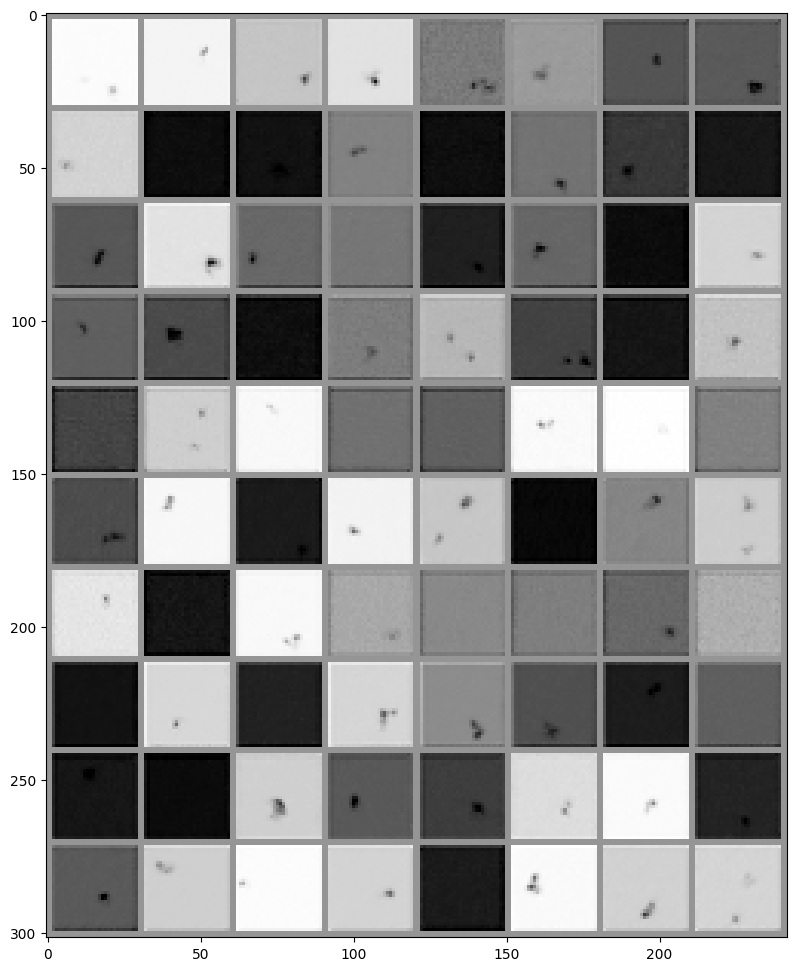

In [12]:
# Prepare random x to start from, plus some desired labels y
x = torch.randn(80, 1, 28, 28).to(device)
y = torch.tensor([[i] * 8 for i in range(10)]).flatten().to(device)

# Sampling loop
for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    # Get model pred
    with torch.no_grad():
        residual = model(x, t, y)  # Again, note that we pass in our labels y

    # Update sample with step
    x = noise_scheduler.step(residual, t, x).prev_sample

# Show the results
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu().clip(-1, 1), nrow=8)[0], cmap="Greys")